In [31]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [32]:
import pandas as pd
import numpy as np
from tqdm import tqdm
from pathlib import Path
from matplotlib import pyplot as plt

from cinc.notebook.detection_results import (
    get_structured_participant_data_df,
    apply_matching_processing,
)

tqdm.pandas()

MATTRESS_LABELS_MAP = {
    "h1": "H1",
    "h2": "H2",
    "h3": "H3",
    "h3_sousmatelas": "H3UM",
    "h3_surcouche": "H3OL",
    "h4": "H4",
}

ID_LABELS_MAP = {
    "v1": "V1",
    "v2": "V2",
    "v3": "V3",
    "v4": "V4",
    "v5": "V5",
    "shanaz": "V6",
    "aurelie": "V7",
    "bastien": "V8",
}

RESPIRATION_CHANNEL = 0

REGULAR_COLOR = '#8da0cb'
QUALITY_COLOR = '#fc8d62'

DF_SAVE_PATH = Path("results.pkl")

## Load Data

In [33]:
structured_participant_data_df = get_structured_participant_data_df()

# Translate mattress labels and remove entries with invalid mattress labels
structured_participant_data_df["mattress"] = (
    structured_participant_data_df["mattress"].map(MATTRESS_LABELS_MAP)
)
structured_participant_data_df = structured_participant_data_df.dropna(subset=["mattress"])

# Translate participant ID labels and remove entries with invalid participant IDs
structured_participant_data_df["id"] = structured_participant_data_df["id"].map(ID_LABELS_MAP)
structured_participant_data_df = structured_participant_data_df.dropna(subset=["id"])

print("Available columns:")
for col in structured_participant_data_df.columns:
    print(f" - {col}")

structured_participant_data_df.head(10)

✅ Found 208 participant files.


⏳ Loading participant data...:   0%|          | 0/208 [00:00<?, ?it/s]

⏳ Loading participant data...: 100%|██████████| 208/208 [01:39<00:00,  2.08it/s]


Available columns:
 - id
 - mattress
 - position
 - psg_cardiac_intervals
 - psg_cardiac_signal
 - psg_cardiac_processed_fs
 - psg_cardiac_upsampled_fs
 - psg_respiratory_c0_intervals
 - psg_respiratory_c1_intervals
 - psg_respiratory_signal
 - psg_respiratory_processed_fs
 - pel_cardiac_sensor_intervals_list
 - pel_cardiac_ensemble_intervals
 - pel_cardiac_signal
 - pel_cardiac_signal_length
 - pel_cardiac_processed_fs
 - pel_cardiac_upsampled_fs
 - pel_respiratory_p0_sensor_intervals_list
 - pel_respiratory_p1_sensor_intervals_list
 - pel_respiratory_p0_ensemble_intervals
 - pel_respiratory_p1_ensemble_intervals
 - pel_respiratory_signal
 - pel_respiratory_signal_length
 - pel_respiratory_processed_fs


,id,mattress,position,psg_cardiac_intervals,psg_cardiac_signal,psg_cardiac_processed_fs,psg_cardiac_upsampled_fs,psg_respiratory_c0_intervals,psg_respiratory_c1_intervals,psg_respiratory_signal,...,pel_cardiac_signal_length,pel_cardiac_processed_fs,pel_cardiac_upsampled_fs,pel_respiratory_p0_sensor_intervals_list,pel_respiratory_p1_sensor_intervals_list,pel_respiratory_p0_ensemble_intervals,pel_respiratory_p1_ensemble_intervals,pel_respiratory_signal,pel_respiratory_signal_length,pel_respiratory_processed_fs
0,V4,H3UM,right,"[[946, 1974], [1974, 2925], [2925, 3859], [385...","[[37.97912603482501, 29.823026916394554, 40.73...",100.0,1000.0,"[[551, 1109], [1109, 1604], [1604, 2083], [208...","[[559, 1118], [1118, 1609], [1609, 2090], [209...","[[11569597.055761311, 11569459.736785242, 1156...",...,18000,100.0,1000.0,"[[[209, 745], [745, 1299], [1299, 1849], [1849...","[[[490, 1046], [1046, 1572], [1572, 2105], [21...","[[178, 705], [705, 1256], [1256, 1809], [1809,...","[[407, 914], [914, 1469], [1469, 2034], [2034,...","[[-3.5628039124439517, -3.498894415472372, -3....",18000,100.0
1,V6,H3OL,prone,"[[572, 1558], [1558, 2592], [2592, 3633], [363...","[[-41.00648007469958, -22.121191598540793, -14...",100.0,1000.0,"[[230, 699], [699, 1082], [1082, 1480], [1480,...","[[208, 665], [665, 1062], [1062, 1466], [1466,...","[[12824729.87583629, 12824636.874688663, 12824...",...,18000,100.0,1000.0,"[[[404, 810], [810, 1214], [1214, 1628], [1628...","[[[207, 629], [629, 1029], [1029, 1446], [1446...","[[380, 784], [784, 1193], [1193, 1606], [1606,...","[[159, 584], [584, 987], [987, 1393], [1393, 1...","[[1.3198201590952143, 1.4144089037605967, 1.45...",18000,100.0
2,V7,H3UM,prone,"[[894, 1795], [1795, 2642], [2642, 3456], [345...","[[-373.10121343769333, -779.2719526787291, -30...",100.0,1000.0,"[[143, 580], [580, 1024], [1024, 1496], [1496,...","[[117, 535], [535, 994], [994, 1464], [1464, 1...","[[13093036.652361767, 13093052.169033991, 1309...",...,18000,100.0,1000.0,"[[[493, 939], [939, 1400], [1400, 1848], [1848...","[[[267, 699], [699, 1161], [1161, 1625], [1625...","[[433, 891], [891, 1352], [1352, 1813], [1813,...","[[219, 666], [666, 1120], [1120, 1593], [1593,...","[[2.213648403954215, 2.836163069815771, 2.9638...",18000,100.0
3,V8,H4,prone,"[[314, 1247], [1247, 2188], [2188, 3093], [309...","[[14.983368881576558, 6.038917323591692, -1.11...",100.0,1000.0,"[[193, 788], [788, 1381], [1381, 1944], [1944,...","[[202, 795], [795, 1385], [1385, 1947], [1947,...","[[13177684.101703465, 13177647.210752726, 1317...",...,18000,100.0,1000.0,"[[[180, 485], [747, 1271], [1832, 2273], [2738...","[[[1475, 2041], [2041, 2384], [2922, 3247], [3...","[[609, 1216], [1216, 1784], [1784, 2366], [236...","[[338, 938], [938, 1519], [1519, 2093], [2093,...","[[-1.4131873409748144, -1.3031079594610946, -1...",18000,100.0
4,V8,H4,left,"[[550, 1649], [1649, 2733], [2733, 3776], [377...","[[-1.5243038464875232, -2.381280557026427, -6....",100.0,1000.0,"[[127, 605], [605, 1059], [1059, 1480], [1480,...","[[164, 614], [614, 1083], [1083, 1497], [1497,...","[[13130302.193347758, 13130423.29116587, 13130...",...,18000,100.0,1000.0,"[[[314, 800], [800, 1255], [1255, 1664], [1664...","[[[121, 543], [543, 1031], [1031, 1465], [1465...","[[451, 929], [929, 1376], [1376, 1780], [1780,...","[[252, 735], [735, 1181], [1181, 1591], [1591,...","[[-0.42955331021790516, -0.5304811787501073, -...",18000,100.0
5,V1,H3UM,prone,"[[1122, 2016], [2016, 2885], [2885, 3738], [37...","[[2.1503559354261186, -0.8771338242771259, 7.4...",100.0,1000.0,"[[778, 1565], [1565, 2322], [2322, 2999], [299...","[[760, 1573], [1573, 2336], [2336, 3023], [302...","[[13222037.999999994, 13221828.146095265, 1322...",...,18000,100.0,1000.0,"[[[161, 889], [889, 1715], [1715, 2454], [2454...","[[[518, 1286], [1286, 2100], [2100, 2798], [27...","[[240, 987], [987, 1840], [1840, 2606], [2606,...","[[607, 1279], [1279, 2117], [2117, 2870], [287...","[[0.5991181325765019, 0.5095790817211648, 0.54..."

In [34]:
new_structured_participant_data_df = apply_matching_processing(structured_participant_data_df)


print("Available columns:")
for col in new_structured_participant_data_df.columns:
    print(f" - {col}")

new_structured_participant_data_df.head()

Applying interval rate estimation...


100%|██████████| 152/152 [00:00<00:00, 4381.86it/s]


Applying interval matching...


100%|██████████| 152/152 [00:00<00:00, 614.41it/s]


Available columns:
 - id
 - mattress
 - position
 - psg_cardiac_intervals
 - psg_cardiac_signal
 - psg_cardiac_processed_fs
 - psg_cardiac_upsampled_fs
 - psg_respiratory_c0_intervals
 - psg_respiratory_c1_intervals
 - psg_respiratory_signal
 - psg_respiratory_processed_fs
 - pel_cardiac_sensor_intervals_list
 - pel_cardiac_ensemble_intervals
 - pel_cardiac_signal
 - pel_cardiac_signal_length
 - pel_cardiac_processed_fs
 - pel_cardiac_upsampled_fs
 - pel_respiratory_p0_sensor_intervals_list
 - pel_respiratory_p1_sensor_intervals_list
 - pel_respiratory_p0_ensemble_intervals
 - pel_respiratory_p1_ensemble_intervals
 - pel_respiratory_signal
 - pel_respiratory_signal_length
 - pel_respiratory_processed_fs
 - psg_cardiac_rates
 - psg_respiratory_c0_rates
 - psg_respiratory_c1_rates
 - pel_cardiac_sensor_rates_list
 - pel_respiratory_p0_sensor_rates_list
 - pel_respiratory_p1_sensor_rates_list
 - pel_cardiac_ensemble_rates
 - pel_respiratory_p0_ensemble_rates
 - pel_respiratory_p1_ensemble

,id,mattress,position,psg_cardiac_intervals,psg_cardiac_signal,psg_cardiac_processed_fs,psg_cardiac_upsampled_fs,psg_respiratory_c0_intervals,psg_respiratory_c1_intervals,psg_respiratory_signal,...,pel_respiratory_sensor_interval_matchings,pel_respiratory_c0_p0_ensemble_interval_matches,pel_respiratory_c0_p0_ensemble_interval_matching,pel_respiratory_c0_p1_ensemble_interval_matches,pel_respiratory_c0_p1_ensemble_interval_matching,pel_respiratory_c1_p0_ensemble_interval_matches,pel_respiratory_c1_p0_ensemble_interval_matching,pel_respiratory_c1_p1_ensemble_interval_matches,pel_respiratory_c1_p1_ensemble_interval_matching,pel_respiratory_ensemble_interval_matching
0,V4,H3UM,right,"[[946, 1974], [1974, 2925], [2925, 3859], [385...","[[37.97912603482501, 29.823026916394554, 40.73...",100.0,1000.0,"[[551, 1109], [1109, 1604], [1604, 2083], [208...","[[559, 1118], [1118, 1609], [1609, 2090], [209...","[[11569597.055761311, 11569459.736785242, 1156...",...,"[50.588235294117645, 52.857142857142854, 60.0,...",[{'rate1': <cinc.notebook.detection_results.Ra...,60.000000,[{'rate1': <cinc.notebook.detection_results.Ra...,48.571429,[{'rate1': <cinc.notebook.detection_results.Ra...,60.000000,[{'rate1': <cinc.notebook.detection_results.Ra...,42.857143,60.000000
1,V6,H3OL,prone,"[[572, 1558], [1558, 2592], [2592, 3633], [363...","[[-41.00648007469958, -22.121191598540793, -14...",100.0,1000.0,"[[230, 699], [699, 1082], [1082, 1480], [1480,...","[[208, 665], [665, 1062], [1062, 1466], [1466,...","[[12824729.87583629, 12824636.874688663, 12824...",...,"[67.11538461538461, 67.94871794871796, 52.8571...",[{'rate1': <cinc.notebook.detection_results.Ra...,40.000000,[{'rate1': <cinc.notebook.detection_results.Ra...,70.000000,[{'rate1': <cinc.notebook.detection_results.Ra...,45.000000,[{'rate1': <cinc.notebook.detection_results.Ra...,80.000000,75.000000
2,V7,H3UM,prone,"[[894, 1795], [1795, 2642], [2642, 3456], [345...","[[-373.10121343769333, -779.2719526787291, -30...",100.0,1000.0,"[[143, 580], [580, 1024], [1024, 1496], [1496,...","[[117, 535], [535, 994], [994, 1464], [1464, 1...","[[13093036.652361767, 13093052.169033991, 1309...",...,"[88.46153846153847, 79.83550765740216, 55.8423...",[{'rate1': <cinc.notebook.detection_results.Ra...,82.500000,[{'rate1': <cinc.notebook.detection_results.Ra...,95.121951,[{'rate1': <cinc.notebook.detection_results.Ra...,85.714286,[{'rate1': <cinc.notebook.detection_results.Ra...,90.697674,92.909813
3,V8,H4,prone,"[[314, 1247], [1247, 2188], [2188, 3093], [309...","[[14.983368881576558, 6.038917323591692, -1.11...",100.0,1000.0,"[[193, 788], [788, 1381], [1381, 1944], [1944,...","[[202, 795], [795, 1385], [1385, 1947], [1947,...","[[13177684.101703465, 13177647.210752726, 1317...",...,"[4.0, 100.0, 54.166666666666664, 96.4285714285...",[{'rate1': <cinc.notebook.detection_results.Ra...,82.142857,[{'rate1': <cinc.notebook.detection_results.Ra...,100.000000,[{'rate1': <cinc.notebook.detection_results.Ra...,92.857143,[{'rate1': <cinc.notebook.detection_results.Ra...,96.428571,98.214286
4,V8,H4,left,"[[550, 1649], [1649, 2733], [2733, 3776], [377...","[[-1.5243038464875232, -2.381280557026427, -6....",100.0,1000.0,"[[127, 605], [605, 1059], [1059, 1480], [1480,...","[[164, 614], [614, 1083], [1083, 1497], [1497,...","[[13130302.193347758, 13130423.29116587, 13130...",...,"[81.45424836601308, 76.8465909090909, 75.57189...",[{'rate1': <cinc.notebook.detection_results.Ra...,68.571429,[{'rate1': <cinc.notebook.detection_results.Ra...,80.555556,[{'rate1': <cinc.notebook.detection_results.Ra...,58.333333,[{'rate1': <cinc.notebook.detection_results.Ra...,91.891892,86.223724


In [35]:
# Save dataframe to disk
structured_participant_data_df.to_pickle(DF_SAVE_PATH)

In [ ]:
# Load dataframe from disk
structured_participant_data_df = pd.read_pickle(DF_SAVE_PATH)

## Outliers

In [36]:
def plot_signal_comparison(
    filtered_df, 
    structured_data_df,
    use_channel=None,
    signal_type='cardiac', 
    time_ranges=None, 
    n_cols=3, 
    figsize_per_plot=(5, 4), 
    margin_top=0.94,
) -> None:
    """Plot signal comparison using new structured data format with intervals."""
    if signal_type.lower() == 'cardiac':
        psg_signal_key = 'psg_cardiac_signal'
        piezo_signal_key = 'pel_cardiac_signal'
        psg_intervals_key = 'psg_cardiac_intervals'
        piezo_intervals_key = 'pel_cardiac_ensemble_intervals' if use_channel is None else 'pel_cardiac_sensor_intervals_list'
        psg_signal_fs_key = 'psg_cardiac_processed_fs'
        piezo_signal_fs_key = 'pel_cardiac_processed_fs'
        psg_intervals_fs_key = 'psg_cardiac_upsampled_fs'
        piezo_intervals_fs_key = 'pel_cardiac_upsampled_fs'
        psg_label = 'PSG Cardiac'
        piezo_label = 'Piezo Cardiac Ensemble' if use_channel is None else f'Piezo Cardiac Ch{use_channel}'
        psg_intervals_label = 'PSG Cardiac Intervals'
        piezo_intervals_label = 'Piezo Cardiac Intervals'
        matching_key = 'cardiac_ensemble_interval_matching'
    elif signal_type.lower() == 'respiratory':
        psg_signal_key = 'psg_respiratory_signal'
        piezo_signal_key = 'pel_respiratory_signal'
        psg_intervals_key = 'psg_respiratory_c0_intervals'
        if use_channel is None:
            piezo_intervals_key = 'pel_respiratory_p0_ensemble_intervals'
        else:
            piezo_intervals_key = 'pel_respiratory_p0_sensor_intervals_list'
        psg_signal_fs_key = 'psg_respiratory_processed_fs'
        piezo_signal_fs_key = 'pel_respiratory_processed_fs'
        psg_intervals_fs_key = 'psg_respiratory_processed_fs'
        piezo_intervals_fs_key = 'pel_respiratory_processed_fs'
        psg_label = 'PSG Respiratory'
        piezo_label = 'Piezo Respiratory Ensemble' if use_channel is None else f'Piezo Respiratory Ch{use_channel}'
        psg_intervals_label = 'PSG Respiratory Intervals'
        piezo_intervals_label = 'Piezo Respiratory Intervals'
        matching_key = 'respiratory_ensemble_interval_matching'
    else:
        raise ValueError("signal_type must be either 'cardiac' or 'respiratory'")
    
    n_participants = len(filtered_df)
    
    # Calculate total rows needed (2 per participant + 1 for spacing between participants)
    n_participant_rows = int(np.ceil(n_participants / n_cols))
    n_rows = n_participant_rows * 3  # 2 for plots + 1 for spacing
    
    # Create figure with subplots
    fig = plt.figure(figsize=(figsize_per_plot[0] * n_cols, figsize_per_plot[1] * n_participants * 2 / n_cols))
    
    # Create grid spec with custom spacing and adjust top/bottom margins
    gs = fig.add_gridspec(nrows=n_rows, ncols=n_cols, 
                          hspace=0.1,    # Minimal spacing for tight pairs
                          wspace=0.3,    # Horizontal spacing
                          top=margin_top,      # Leave small space at top for legend
                          bottom=0.05,   # Small margin at bottom
                          left=0.08,     # Left margin
                          right=0.95,    # Right margin
                          height_ratios=[1, 1, 0.5] * n_participant_rows)  # 2 plots + larger spacing
    
    legend_handles = []
    legend_labels = []
    
    for i, (_, row) in enumerate(filtered_df.iterrows()):
        participant_id = row["id"]
        participant_mattress = row["mattress"]
        participant_position = row["position"]
        
        participant_data = structured_data_df[
            (structured_data_df["id"] == participant_id) &
            (structured_data_df["mattress"] == participant_mattress) &
            (structured_data_df["position"] == participant_position)
        ].iloc[0]
        
        # Calculate subplot positions
        col = i % n_cols
        participant_row = i // n_cols
        row_start = participant_row * 3  # Skip spacing rows
        
        # Create two independent subplots: Piezo on top, PSG on bottom
        ax_piezo = fig.add_subplot(gs[row_start, col])
        ax_psg = fig.add_subplot(gs[row_start + 1, col])
        
        # Get signals
        psg_signal = participant_data[psg_signal_key]
        if signal_type.lower() == 'respiratory':
            psg_signal = psg_signal[RESPIRATION_CHANNEL].flatten()
        else:
            psg_signal = psg_signal.flatten()
        
        # Get piezo signal and intervals
        if use_channel is None:
            # For ensemble, take the mean of all channels or first channel
            piezo_signal_raw = participant_data[piezo_signal_key]
            # Check if it's 2D (multiple channels)
            if piezo_signal_raw.ndim == 2:
                # Take mean across channels (axis 0)
                piezo_signal = np.mean(piezo_signal_raw, axis=0).flatten()
            else:
                piezo_signal = piezo_signal_raw.flatten()
            piezo_intervals = participant_data[piezo_intervals_key]
        else:
            piezo_signal = participant_data[piezo_signal_key][use_channel].flatten()
            piezo_intervals = participant_data[piezo_intervals_key][use_channel]
        
        psg_intervals = participant_data[psg_intervals_key]
        
        psg_time = np.arange(len(psg_signal)) / participant_data[psg_signal_fs_key]
        piezo_time = np.arange(len(piezo_signal)) / participant_data[piezo_signal_fs_key]
        
        # Plot Piezo signal (top)
        line_piezo = ax_piezo.plot(piezo_time, piezo_signal, color='blue', alpha=0.7, label=piezo_label)[0]
        
        # Plot piezo intervals as vertical spans
        interval_piezo = None
        if len(piezo_intervals) > 0:
            for interval in piezo_intervals:
                start_idx, end_idx = interval
                # Convert from intervals_fs space to time
                start_time = start_idx / participant_data[piezo_intervals_fs_key]
                end_time = end_idx / participant_data[piezo_intervals_fs_key]
                interval_piezo = ax_piezo.axvspan(start_time, end_time, alpha=0.2, color='darkblue', label=piezo_intervals_label if interval_piezo is None else "")
        
        # Plot PSG signal (bottom)
        line_psg = ax_psg.plot(psg_time, psg_signal, color='red', alpha=0.7, label=psg_label)[0]
        
        # Plot psg intervals as vertical spans
        interval_psg = None
        if len(psg_intervals) > 0:
            for interval in psg_intervals:
                start_idx, end_idx = interval
                # Convert from intervals_fs space to time
                start_time = start_idx / participant_data[psg_intervals_fs_key]
                end_time = end_idx / participant_data[psg_intervals_fs_key]
                interval_psg = ax_psg.axvspan(start_time, end_time, alpha=0.2, color='darkred', label=psg_intervals_label if interval_psg is None else "")
        
        # Store legend items from first participant
        if i == 0:
            legend_handles = [line_piezo, line_psg]
            legend_labels = [piezo_label, psg_label]
            if interval_piezo is not None:
                legend_handles.append(interval_piezo)
                legend_labels.append(piezo_intervals_label)
            if interval_psg is not None:
                legend_handles.append(interval_psg)
                legend_labels.append(psg_intervals_label)
        
        # Set title on TOP plot only
        matching_score = row.get(matching_key, "N/A")
        title = f"Participant {participant_id} - {participant_mattress} - {participant_position}"
        if matching_score != "N/A":
            title += f"\nMatching: {matching_score:.2f}%"
        
        ax_piezo.set_title(title, fontsize=9, pad=10)
        
        # Labels for piezo (top plot) - no x-axis label
        ax_piezo.set_ylabel(piezo_label, fontsize=8)
        ax_piezo.tick_params(axis='y', labelsize=7)
        ax_piezo.tick_params(axis='x', labelbottom=False)  # Hide x-tick labels
        
        # Labels for psg (bottom plot) - with x-axis label
        ax_psg.set_xlabel("Time (s)", fontsize=8)
        ax_psg.set_ylabel(psg_label, fontsize=8)
        ax_psg.tick_params(axis='y', labelsize=7)
        ax_psg.tick_params(axis='x', labelsize=7)
        
        # Apply time range if specified
        x_start = None
        x_end = None
        
        if time_ranges is not None:
            if isinstance(time_ranges, dict):
                key = (participant_id, participant_mattress, participant_position)
                if key in time_ranges:
                    x_start, x_end = time_ranges[key]
            elif isinstance(time_ranges, list):
                if i < len(time_ranges):
                    x_start, x_end = time_ranges[i]
        
        if x_start is not None and x_end is not None:
            # Apply to both plots
            ax_piezo.set_xlim(x_start, x_end)
            ax_psg.set_xlim(x_start, x_end)
            
            psg_mask = (psg_time >= x_start) & (psg_time <= x_end)
            piezo_mask = (piezo_time >= x_start) & (piezo_time <= x_end)
            
            if np.any(psg_mask):
                psg_data_in_range = psg_signal[psg_mask]
                psg_min = np.min(psg_data_in_range)
                psg_max = np.max(psg_data_in_range)
                psg_margin = (psg_max - psg_min) * 0.1
                ax_psg.set_ylim(psg_min - psg_margin, psg_max + psg_margin)
            
            if np.any(piezo_mask):
                piezo_data_in_range = piezo_signal[piezo_mask]
                piezo_min = np.min(piezo_data_in_range)
                piezo_max = np.max(piezo_data_in_range)
                piezo_margin = (piezo_max - piezo_min) * 0.1
                ax_piezo.set_ylim(piezo_min - piezo_margin, piezo_max + piezo_margin)
    
    # Create legend handles
    legend_handles = []
    legend_labels = []
    # Create dummy lines for main signals
    dummy_piezo_line = plt.Line2D([], [], color='blue', label=piezo_label)
    legend_handles.append(dummy_piezo_line)
    legend_labels.append(piezo_label)
    dummy_psg_line = plt.Line2D([], [], color='red', label=psg_label)
    legend_handles.append(dummy_psg_line)
    legend_labels.append(psg_label)
    # Create dummy patches for intervals
    from matplotlib.patches import Patch
    dummy_piezo_interval = Patch(facecolor='darkblue', alpha=0.2, label=piezo_intervals_label)
    legend_handles.append(dummy_piezo_interval)
    legend_labels.append(piezo_intervals_label)
    dummy_psg_interval = Patch(facecolor='darkred', alpha=0.2, label=psg_intervals_label)
    legend_handles.append(dummy_psg_interval)
    legend_labels.append(psg_intervals_label)
    
    # Add legend at the top
    fig.legend(legend_handles, legend_labels, loc='upper center', bbox_to_anchor=(0.5, 1.0), 
               ncol=4, frameon=True, fontsize=9)
    
    plt.show()

In [37]:
cardiac_interval_outliers_df = structured_participant_data_df[["id", "mattress", "position", "pel_cardiac_ensemble_interval_matching"]]
cardiac_interval_outliers_df = cardiac_interval_outliers_df.sort_values(by="pel_cardiac_ensemble_interval_matching", ascending=True)

filtered_cardiac_interval_outliers_df = cardiac_interval_outliers_df[cardiac_interval_outliers_df["pel_cardiac_ensemble_interval_matching"] < 50]
filtered_cardiac_interval_outliers_df.head(15)

,id,mattress,position,pel_cardiac_ensemble_interval_matching
25,V1,H4,prone,0.000000
103,V4,H1,left,0.000000
145,V4,H1,supine,0.000000
179,V4,H1,right,0.000000
128,V4,H1,prone,0.751880
15,V5,H1,right,1.801802
104,V3,H3UM,left,5.755396
127,V1,H1,right,15.384615
168,V7,H3UM,left,23.762376
189,V1,H1,prone,27.586207


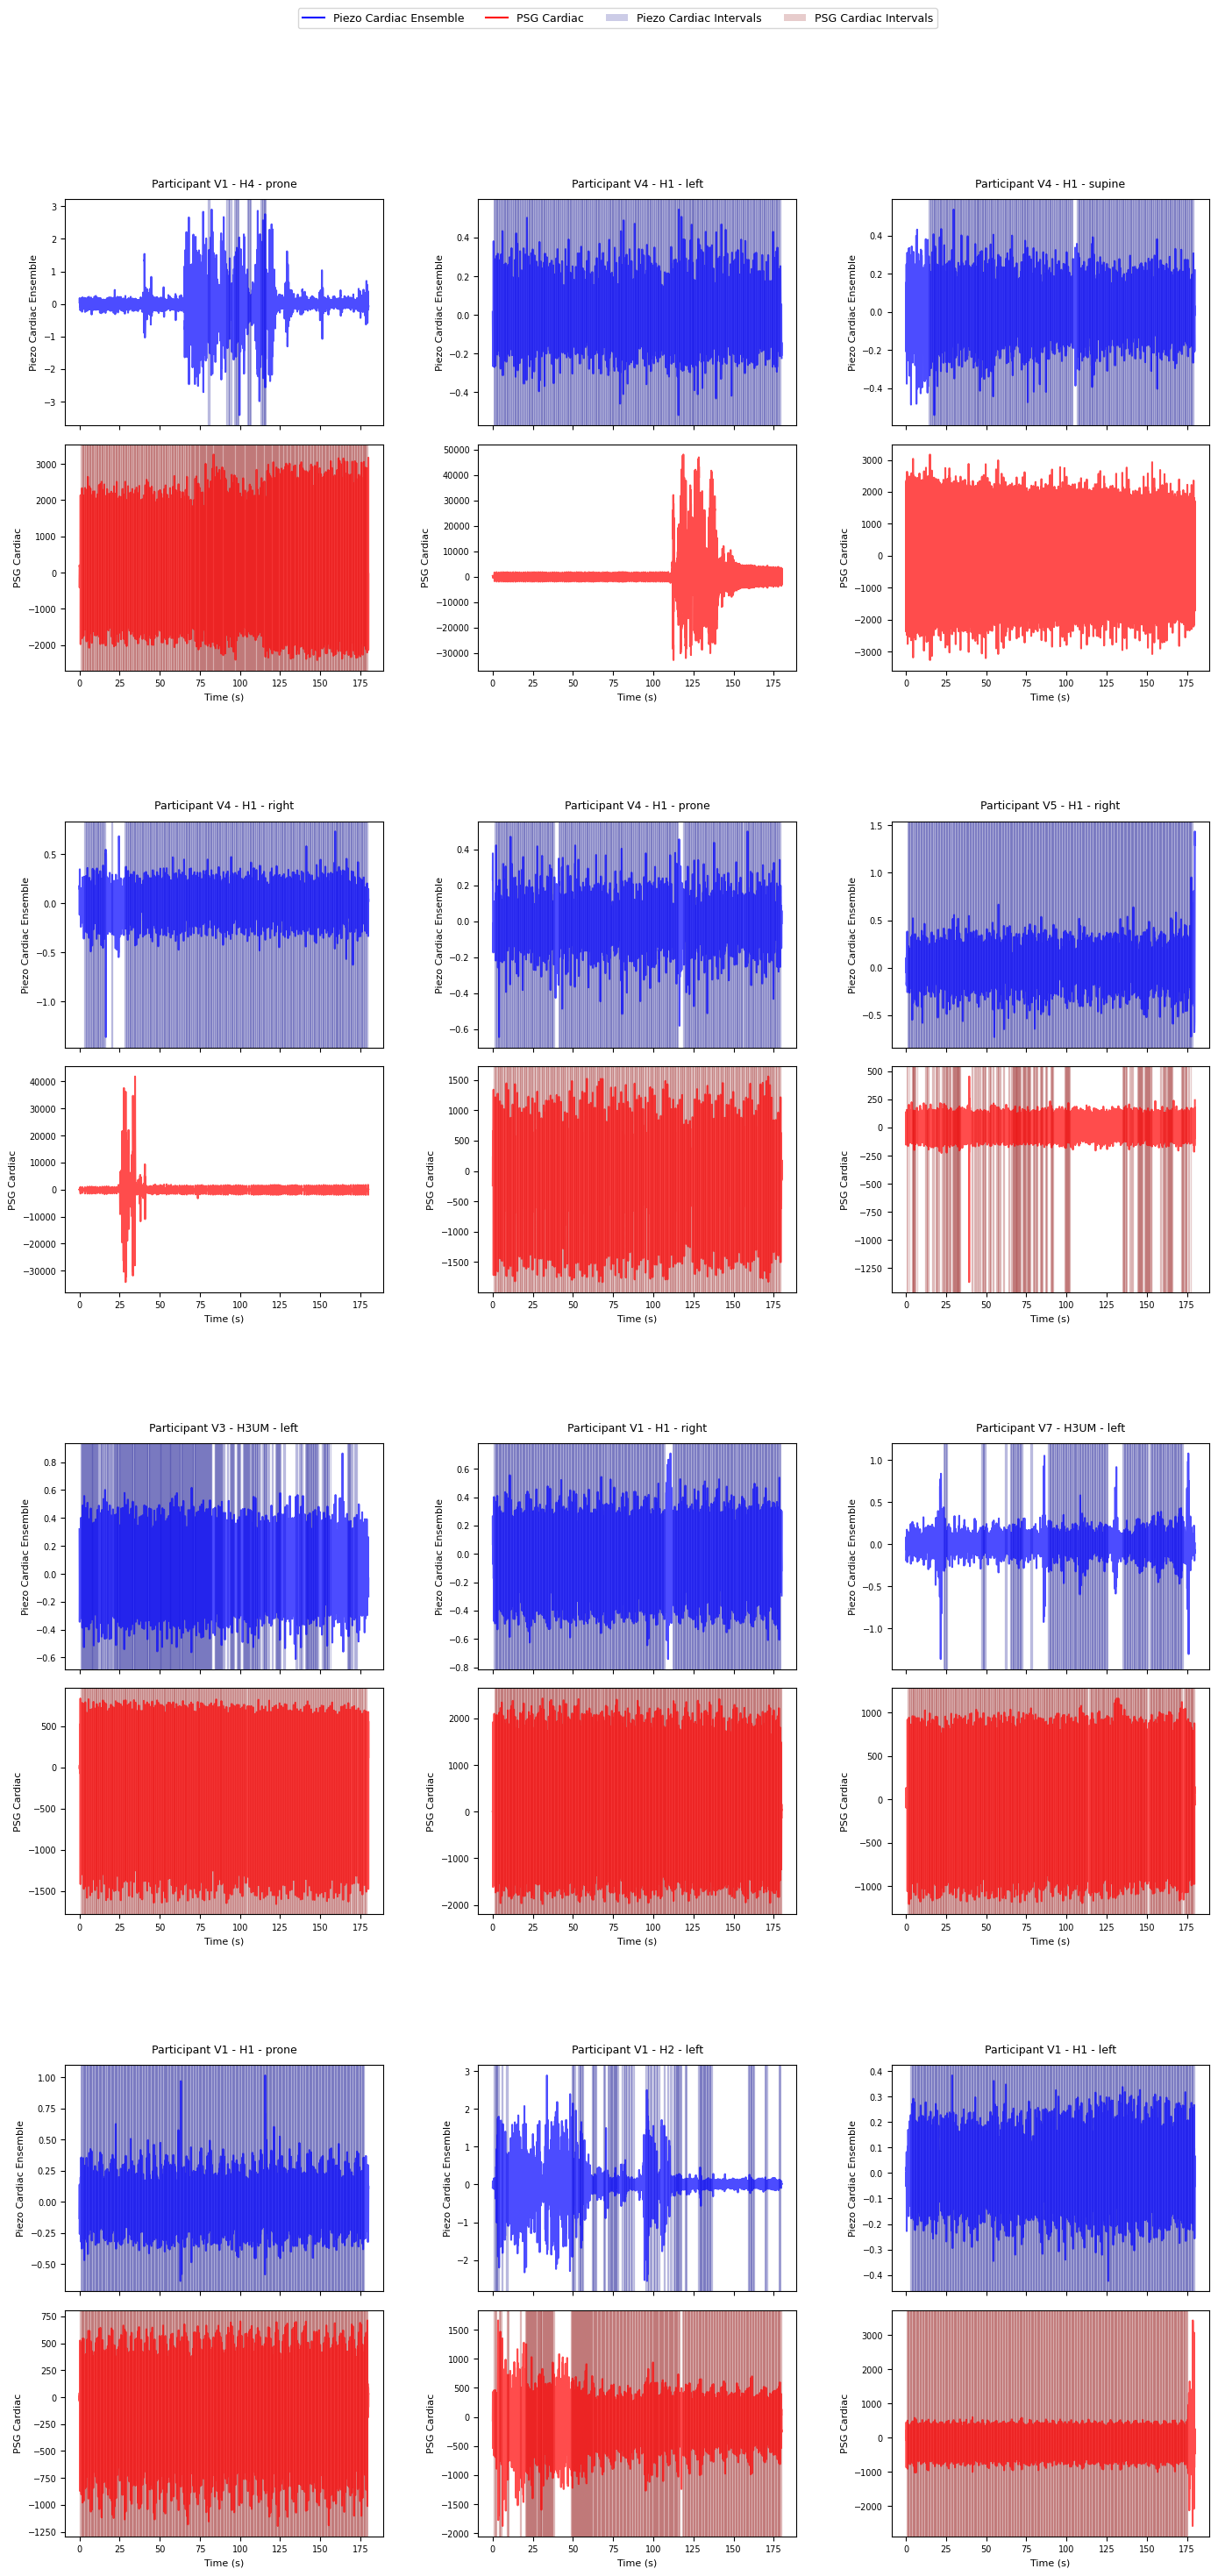

In [38]:
time_ranges_dict = {
}

plot_signal_comparison(
    filtered_df=filtered_cardiac_interval_outliers_df, 
    structured_data_df=structured_participant_data_df,
    signal_type="cardiac",
    time_ranges=time_ranges_dict,
    margin_top=0.93,
)

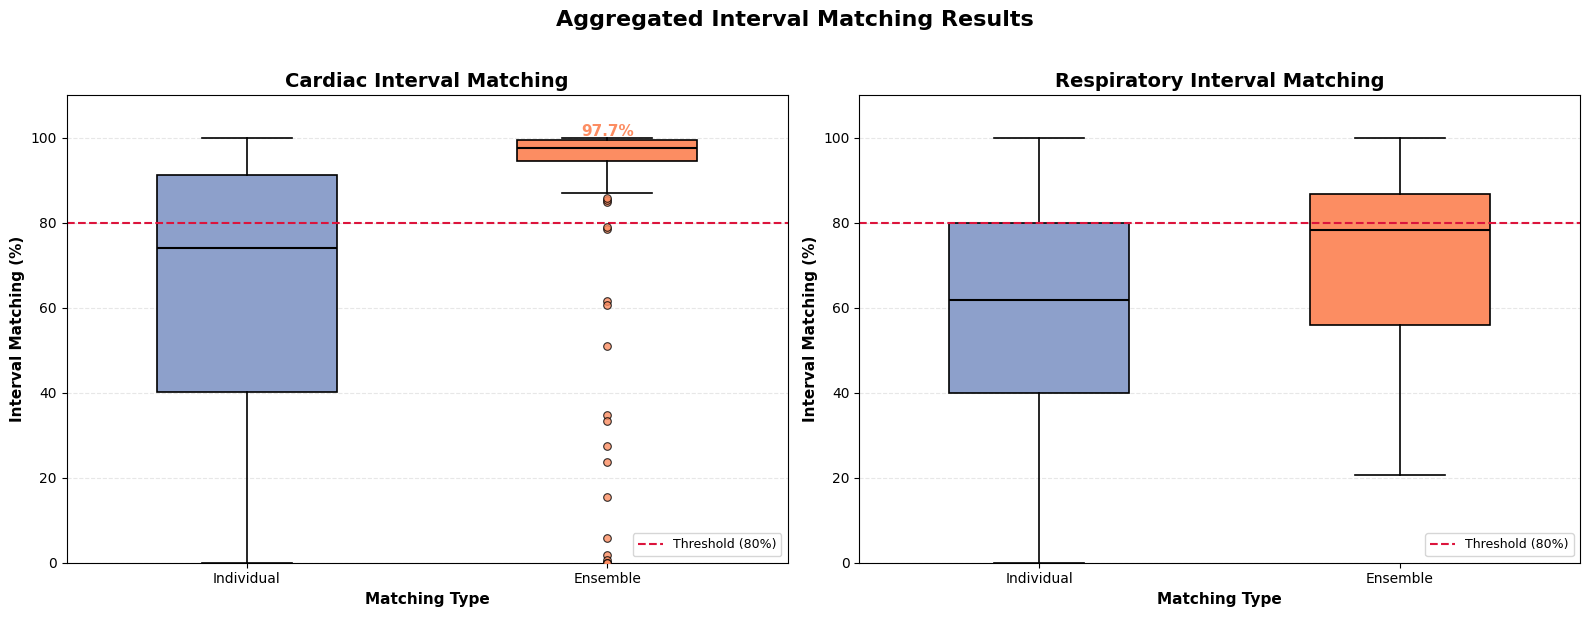


SUMMARY TABLE: Interval Matching Results (Median / Mean ± Std)

Cardiac Interval Matching:
--------------------------------------------------
  Individual  : median= 74.2%  mean= 63.5% ±  32.4%  (n=2432)
  Ensemble    : median= 97.7%  mean= 89.4% ±  24.0%  (n=152)

Respiratory Interval Matching:
--------------------------------------------------
  Individual  : median= 61.8%  mean= 58.3% ±  25.9%  (n=2432)
  Ensemble    : median= 78.2%  mean= 71.1% ±  20.7%  (n=152)


Raw summary data:
        Signal Matching_Type  Mean (%)  Std (%)  Median (%)  Count
0      Cardiac    Individual     63.52    32.44       74.16   2432
1      Cardiac      Ensemble     89.41    24.01       97.66    152
2  Respiratory    Individual     58.30    25.94       61.84   2432
3  Respiratory      Ensemble     71.12    20.69       78.24    152


In [12]:
def plot_matching_aggregated_subplots(df: pd.DataFrame, threshold: float, print_summary=True):
    # Define the signal types
    signal_types = ['cardiac', 'respiratory']
    
    # Create subplots: 1 row x 2 columns (cardiac and respiratory)
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    # Store results for summary table
    summary_data = []
    
    for idx, signal_type in enumerate(signal_types):
        ax = axes[idx]
        
        # Column names based on signal type
        sensor_matchings_col = f'pel_{signal_type}_sensor_interval_matchings'
        ensemble_matching_col = f'pel_{signal_type}_ensemble_interval_matching'
            
        # Prepare data for plotting
        data_list = []
        
        # Individual: explode the sensor matchings list
        individual_df = df[[sensor_matchings_col]].explode(sensor_matchings_col).copy()
        individual_df['matching_type'] = 'Individual'
        individual_df['value'] = individual_df[sensor_matchings_col]
        data_list.append(individual_df[['matching_type', 'value']])
        
        # Ensemble: use ensemble matching directly
        ensemble_df = df[[ensemble_matching_col]].copy()
        ensemble_df['matching_type'] = 'Ensemble'
        ensemble_df['value'] = ensemble_df[ensemble_matching_col]
        data_list.append(ensemble_df[['matching_type', 'value']])
        
        plot_df = pd.concat(data_list, ignore_index=True)
        plot_df['value'] = pd.to_numeric(plot_df['value'], errors='coerce')
        
        matching_types = ['Individual', 'Ensemble']
        colors = [REGULAR_COLOR, QUALITY_COLOR]
        
        # Build box plot data
        box_data = []
        for matching_type in matching_types:
            type_data = plot_df[plot_df['matching_type'] == matching_type]['value'].dropna()
            box_data.append(type_data.values)
            
            # Store for summary table
            signal_label = signal_type.capitalize()
            summary_data.append({
                'Signal': signal_label,
                'Matching_Type': matching_type,
                'Mean (%)': type_data.mean(),
                'Std (%)': type_data.std(),
                'Median (%)': type_data.median(),
                'Count': len(type_data)
            })
        
        # Create box plots
        bp = ax.boxplot(
            box_data,
            positions=range(len(matching_types)),
            widths=0.5,
            patch_artist=True,
            showfliers=False,
            medianprops=dict(color='black', linewidth=1.5),
            whiskerprops=dict(linewidth=1.2),
            capprops=dict(linewidth=1.2),
        )
        
        # Color the boxes
        for patch, color in zip(bp['boxes'], colors):
            patch.set_facecolor(color)
            patch.set_edgecolor('black')
            patch.set_linewidth(1.2)
        
        # Add outliers as scatter points
        for i, (data, color) in enumerate(zip(box_data, colors)):
            q1 = np.percentile(data, 25)
            q3 = np.percentile(data, 75)
            iqr = q3 - q1
            lower = q1 - 1.5 * iqr
            upper = q3 + 1.5 * iqr
            outliers = data[(data < lower) | (data > upper)]
            ax.scatter(
                np.full_like(outliers, i), outliers,
                color=color, edgecolors='black', linewidth=0.8,
                zorder=5, s=30, alpha=0.8,
            )
        
        # Add median values as text
        for i, data in enumerate(box_data):
            median_val = np.median(data)
            ax.text(i, median_val + 2, f'{median_val:.1f}%',
                    ha='center', va='bottom', fontsize=11, fontweight='bold', color=colors[i])
            
        # Add threshold line if applicable
        if threshold is not None:
            ax.axhline(y=threshold, color='crimson', linestyle='--', linewidth=1.5, 
                      label=f'Threshold ({threshold}%)')
        
        # Formatting
        signal_label = signal_type.capitalize()
        title = f"{signal_label} Interval Matching"
        
        ax.set_title(title, fontsize=14, fontweight='bold')
        ax.set_ylabel('Interval Matching (%)', fontsize=11, fontweight='bold')
        ax.set_xlabel("Matching Type", fontsize=11, fontweight='bold')
        ax.set_xticks(range(len(matching_types)))
        ax.set_xticklabels(matching_types, fontsize=10)
        ax.set_ylim(0, 110)
        ax.grid(axis='y', alpha=0.3, linestyle='--')
        
        if threshold is not None:
            ax.legend(loc='lower right', fontsize=9)
    
    plt.suptitle("Aggregated Interval Matching Results", fontsize=16, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()
    
    # Create and display summary table
    summary_df = pd.DataFrame(summary_data)
    
    if print_summary:
        print("\n" + "="*80)
        print("SUMMARY TABLE: Interval Matching Results (Median / Mean ± Std)")
        print("="*80)
        
        for signal in ['Cardiac', 'Respiratory']:
            print(f"\n{signal} Interval Matching:")
            print("-" * 50)
            for matching_type in ['Individual', 'Ensemble']:
                row = summary_df[(summary_df['Signal'] == signal) & 
                                (summary_df['Matching_Type'] == matching_type)]
                if not row.empty:
                    mean_val = row['Mean (%)'].values[0]
                    std_val = row['Std (%)'].values[0]
                    median_val = row['Median (%)'].values[0]
                    count = row['Count'].values[0]
                    print(f"  {matching_type:12}: median={median_val:5.1f}%  mean={mean_val:5.1f}% ± {std_val:5.1f}%  (n={count})")
        
        print("\n" + "="*80)
    
    return summary_df

summary_table = plot_matching_aggregated_subplots(
    structured_participant_data_df, 
    threshold=80, 
    print_summary=True
)

print("\nRaw summary data:")
print(summary_table.round(2))